# Amazon vs eBay: Financial Performance and Stock Return Comparison

This notebook presents a comparison of Amazon and eBay using accounting data and stock market data.  
The purpose of the analysis is to examine differences between the two firms in terms of business scale, profitability, and stock return performance over time.

The notebook uses:
- **Compustat** for accounting variables
- **CRSP** for stock return data
- **CCM link table** to match firm identifiers across the two databases

## Research objective

The main objective of this notebook is to compare Amazon and eBay as two major firms in the e-commerce sector.  
The analysis focuses on the following questions:

1. How do the two firms differ in terms of sales, total assets, and net income?  
2. Which firm shows stronger profitability, measured by return on assets (ROA)?  
3. How do their annual stock returns compare over the sample period?  
4. Is higher profitability associated with stronger stock return performance?

This notebook is intended as a firm-level comparison rather than a broad market-wide study.

In [ ]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## Connect to WRDS
This step connects to WRDS and allows access to Compustat and CRSP data.

In [123]:
username = "wangzzzhhh" 
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## Identify target companies## Identify sample firms
Amazon and eBay are selected as the sample firms because both are well-known e-commerce companies with different business models and growth patterns.
The analysis focuses on Amazon and eBay. Their security identifiers are obtained from CRSP.

In [124]:
ecom_sql = """
SELECT DISTINCT permno, ticker, comnam, namedt, nameenddt
FROM crsp.stocknames
WHERE ticker IN ('AMZN', 'EBAY')
"""
ecom = db.raw_sql(ecom_sql)

print("Sample firms shape:", ecom.shape)
ecom.head()

Sample firms shape: (4, 5)


,permno,ticker,comnam,namedt,nameenddt
0,82259,EBAY,EASTBAY INC,1995-09-29,1997-01-30
1,84788,AMZN,AMAZON COM INC,1997-05-15,2024-12-31
2,86356,EBAY,EBAY INC,1998-09-24,2007-08-02
3,86356,EBAY,EBAY INC,2007-08-03,2024-12-31


## Download accounting data
Accounting data are obtained from Compustat.  
The variables used in this analysis are:

- `ni`: net income
- `at`: total assets
- `sale`: sales

These variables allow comparison of profitability and company scale.

In [125]:
comp_sql = """
SELECT gvkey, datadate, fyear, ni, at, sale
FROM comp.funda
WHERE ni IS NOT NULL
  AND at IS NOT NULL
  AND at > 0
  AND sale IS NOT NULL
  AND datadate >= '2015-01-01'
"""
comp = db.raw_sql(comp_sql)

comp['datadate'] = pd.to_datetime(comp['datadate'])
comp['year'] = comp['datadate'].dt.year

print("Compustat shape:", comp.shape)
comp.head()

Compustat shape: (148519, 7)


,gvkey,datadate,fyear,ni,at,sale,year
0,001004,2015-05-31,2014,10.2,1515.0,1594.3,2015
1,001004,2016-05-31,2015,47.7,1442.1,1662.6,2016
2,001004,2016-05-31,2015,47.7,1456.0,1525.4,2016
3,001004,2017-05-31,2016,56.5,1504.1,1767.6,2017
4,001004,2017-05-31,2016,56.5,1504.1,1590.8,2017


## Match firm identifiers across databases
The CCM link table is used to connect Compustat firm identifiers (`gvkey`) with CRSP stock identifiers (`permno`).

In [126]:
link_sql = """
SELECT gvkey, lpermno AS permno, linkdt, linkenddt, linktype, linkprim
FROM crsp.ccmxpf_linktable
WHERE linktype IN ('LU', 'LC')
  AND linkprim IN ('P', 'C')
"""
link = db.raw_sql(link_sql)

link['linkdt'] = pd.to_datetime(link['linkdt'])
link['linkenddt'] = pd.to_datetime(link['linkenddt'])
link['linkenddt'] = link['linkenddt'].fillna(pd.Timestamp.today())

print("Link table shape:", link.shape)
link.head()

Link table shape: (33324, 6)


,gvkey,permno,linkdt,linkenddt,linktype,linkprim
0,001000,25881.0,1970-11-13,1978-06-30 00:00:00.000000,LU,P
1,001001,10015.0,1983-09-20,1986-07-31 00:00:00.000000,LU,P
2,001002,10023.0,1972-12-14,1973-06-05 00:00:00.000000,LC,C
3,001003,10031.0,1983-12-07,1989-08-16 00:00:00.000000,LU,C
4,001004,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P


## Create the matched accounting sample
Only valid link periods are retained when matching Compustat with CRSP..

In [127]:
comp_linked = pd.merge(comp, link, on='gvkey', how='inner')

comp_linked = comp_linked[
    (comp_linked['datadate'] >= comp_linked['linkdt']) &
    (comp_linked['datadate'] <= comp_linked['linkenddt'])
]

print("Linked Compustat shape:", comp_linked.shape)
comp_linked.head()

Linked Compustat shape: (94928, 12)


,gvkey,datadate,fyear,ni,at,sale,year,permno,linkdt,linkenddt,linktype,linkprim
0,001004,2015-05-31,2014,10.2,1515.0,1594.3,2015,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P
1,001004,2016-05-31,2015,47.7,1442.1,1662.6,2016,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P
2,001004,2016-05-31,2015,47.7,1456.0,1525.4,2016,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P
3,001004,2017-05-31,2016,56.5,1504.1,1767.6,2017,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P
4,001004,2017-05-31,2016,56.5,1504.1,1590.8,2017,54594.0,1972-04-24,2026-04-27 16:19:42.595535,LU,P


## Keep Amazon and eBay only

In [128]:
target_permnos = ecom['permno'].dropna().unique()

comp_ecom = comp_linked[comp_linked['permno'].isin(target_permnos)].copy()

comp_ecom = comp_ecom.merge(
    ecom[['permno', 'ticker', 'comnam']].drop_duplicates(),
    on='permno',
    how='left'
)

print("E-commerce accounting sample shape:", comp_ecom.shape)
comp_ecom.head()

E-commerce accounting sample shape: (39, 14)


,gvkey,datadate,fyear,ni,at,sale,year,permno,linkdt,linkenddt,linktype,linkprim,ticker,comnam
0,064768,2015-12-31,2015,596.0,65444.0,107006.0,2015,84788.0,1997-05-15,2026-04-27 16:19:42.595535,LC,P,AMZN,AMAZON COM INC
1,064768,2016-12-31,2016,2371.0,83402.0,135987.0,2016,84788.0,1997-05-15,2026-04-27 16:19:42.595535,LC,P,AMZN,AMAZON COM INC
2,064768,2016-12-31,2016,2371.0,83402.0,135987.0,2016,84788.0,1997-05-15,2026-04-27 16:19:42.595535,LC,P,AMZN,AMAZON COM INC
3,064768,2017-12-31,2017,3033.0,131310.0,177866.0,2017,84788.0,1997-05-15,2026-04-27 16:19:42.595535,LC,P,AMZN,AMAZON COM INC
4,064768,2017-12-31,2017,3033.0,131310.0,177866.0,2017,84788.0,1997-05-15,2026-04-27 16:19:42.595535,LC,P,AMZN,AMAZON COM INC


## Construct accounting measures
ROA is calculated as net income divided by total assets.  
This variable is used as a measure of profitability.

In [129]:
comp_ecom['roa'] = comp_ecom['ni'] / comp_ecom['at']

comp_ecom = comp_ecom.dropna(subset=['roa', 'sale', 'ni', 'at'])
comp_ecom = comp_ecom[np.isfinite(comp_ecom['roa'])]

print(comp_ecom[['ticker', 'comnam', 'year', 'sale', 'ni', 'at', 'roa']].head())

  ticker          comnam  year      sale      ni        at       roa
0   AMZN  AMAZON COM INC  2015  107006.0   596.0   65444.0  0.009107
1   AMZN  AMAZON COM INC  2016  135987.0  2371.0   83402.0  0.028429
2   AMZN  AMAZON COM INC  2016  135987.0  2371.0   83402.0  0.028429
3   AMZN  AMAZON COM INC  2017  177866.0  3033.0  131310.0  0.023098
4   AMZN  AMAZON COM INC  2017  177866.0  3033.0  131310.0  0.023098


## Handle extreme values
To reduce the influence of extreme observations, selected accounting variables are winsorized at the 1st and 99th percentiles.  
This step helps improve the stability of the descriptive analysis and regression results.

In [130]:
def winsorize_series(s, lower=0.01, upper=0.99):
    lower_bound = s.quantile(lower)
    upper_bound = s.quantile(upper)
    return s.clip(lower=lower_bound, upper=upper_bound)

comp_ecom['roa_w'] = winsorize_series(comp_ecom['roa'])
comp_ecom['ni_w'] = winsorize_series(comp_ecom['ni'])
comp_ecom['sale_w'] = winsorize_series(comp_ecom['sale'])
comp_ecom['at_w'] = winsorize_series(comp_ecom['at'])

## Summary statistics for accounting variables

In [131]:
comp_ecom[['sale_w', 'ni_w', 'at_w', 'roa_w']].describe()

,sale_w,ni_w,at_w,roa_w
count,39.0,39.0,39.0,39.0
mean,218967.793333,14281.871795,205092.820513,0.101575
std,244951.403962,21258.908753,242763.863813,0.125142
min,7870.94,-2722.0,17610.0,-0.060863
25%,10277.0,1975.0,20850.0,0.039937
50%,135987.0,3033.0,83402.0,0.079334
75%,427943.0,17469.5,370872.0,0.10643
max,716924.0,77670.0,818042.0,0.511079


## Compare accounting performance by company
This table compares the average sales, net income, total assets, and ROA of Amazon and eBay.

In [132]:
acct_summary = comp_ecom.groupby('ticker')[['sale_w', 'ni_w', 'at_w', 'roa_w']].mean().reset_index()
acct_summary

,ticker,sale_w,ni_w,at_w,roa_w
0,AMZN,398124.0,23493.238095,362908.47619,0.053021
1,EBAY,9952.218889,3535.277778,20974.555556,0.158221


## Average sales by company

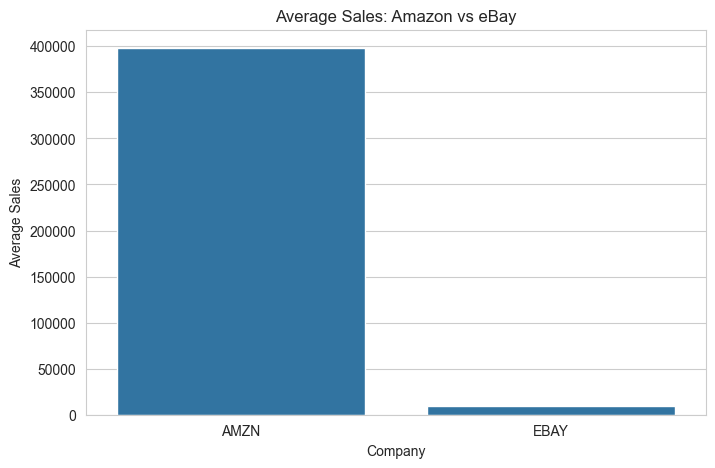

In [133]:
plt.figure(figsize=(8, 5))
sns.barplot(data=acct_summary, x='ticker', y='sale_w')
plt.title('Average Sales: Amazon vs eBay')
plt.xlabel('Company')
plt.ylabel('Average Sales')
plt.show()

## Average total assets by company

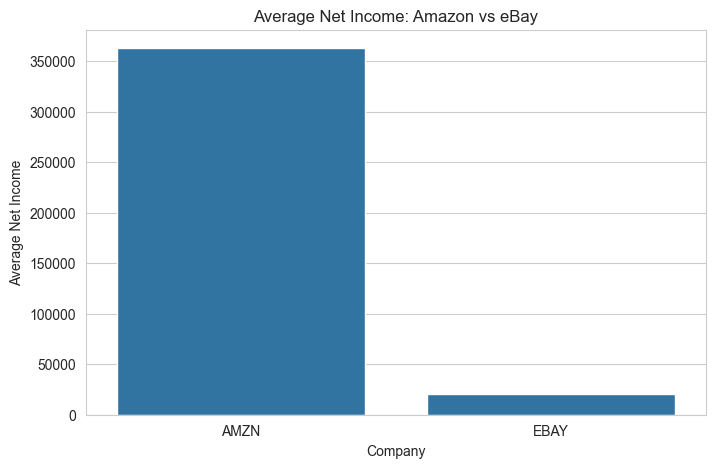

In [134]:
plt.figure(figsize=(8, 5))
sns.barplot(data=acct_summary, x='ticker', y='at_w')
plt.title('Average Net Income: Amazon vs eBay')
plt.xlabel('Company')
plt.ylabel('Average Net Income')
plt.show()

## Average ROA by company

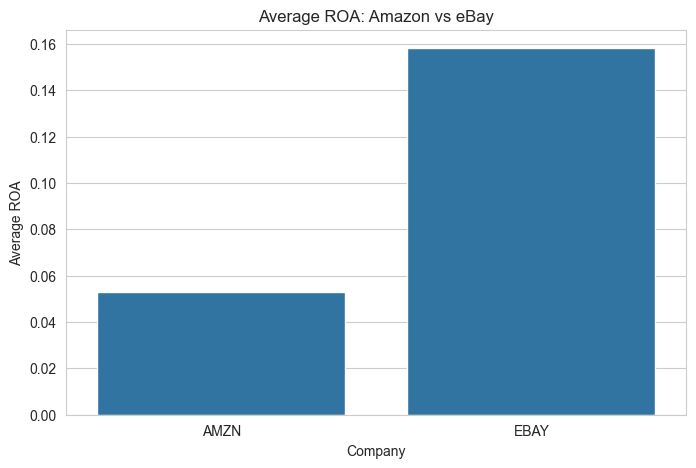

In [135]:
plt.figure(figsize=(8, 5))
sns.barplot(data=acct_summary, x='ticker', y='roa_w')
plt.title('Average ROA: Amazon vs eBay')
plt.xlabel('Company')
plt.ylabel('Average ROA')
plt.show()

## Accounting performance over time
The following figures compare how sales, total assets, net income, and ROA change over time for the two firms.

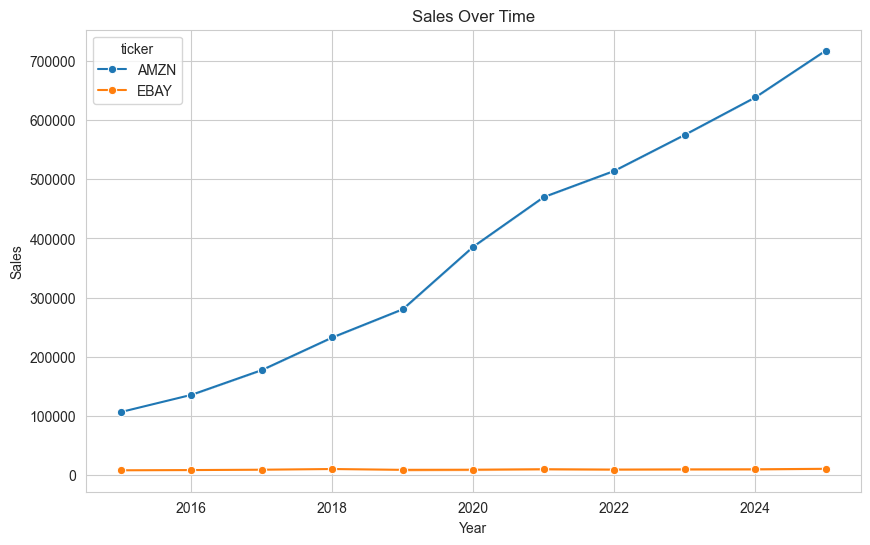

In [136]:
#Sale trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=comp_ecom, x='year', y='sale_w', hue='ticker', marker='o')
plt.title('Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

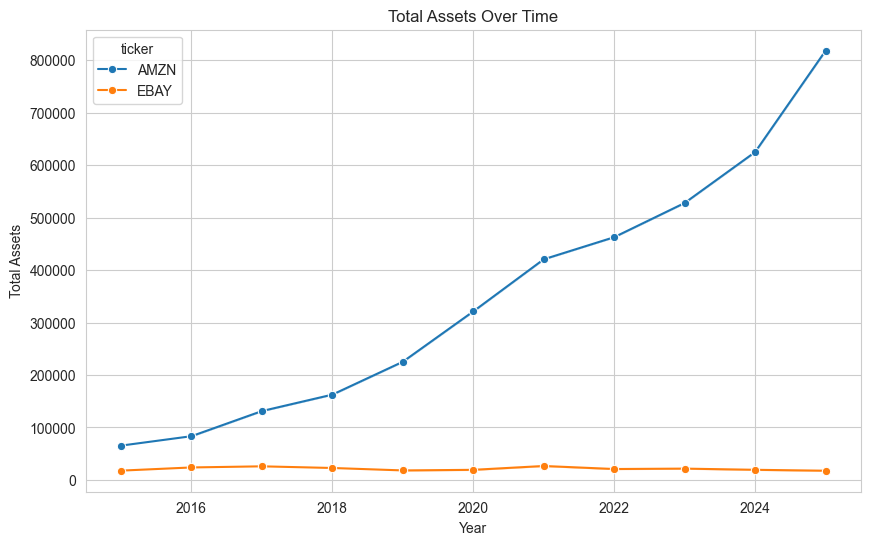

In [137]:
#Assets trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=comp_ecom, x='year', y='at_w', hue='ticker', marker='o')
plt.title('Total Assets Over Time')
plt.xlabel('Year')
plt.ylabel('Total Assets')
plt.show()

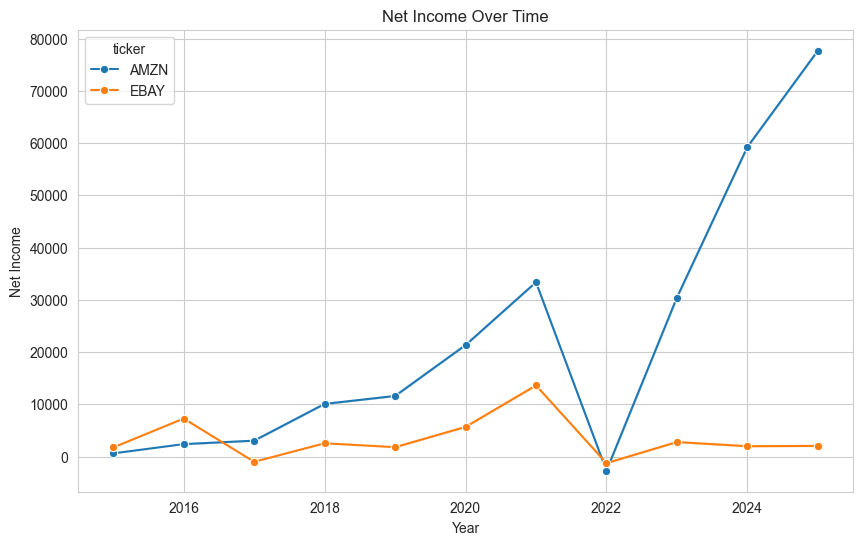

In [138]:
#Net income trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=comp_ecom, x='year', y='ni_w', hue='ticker', marker='o')
plt.title('Net Income Over Time')
plt.xlabel('Year')
plt.ylabel('Net Income')
plt.show()

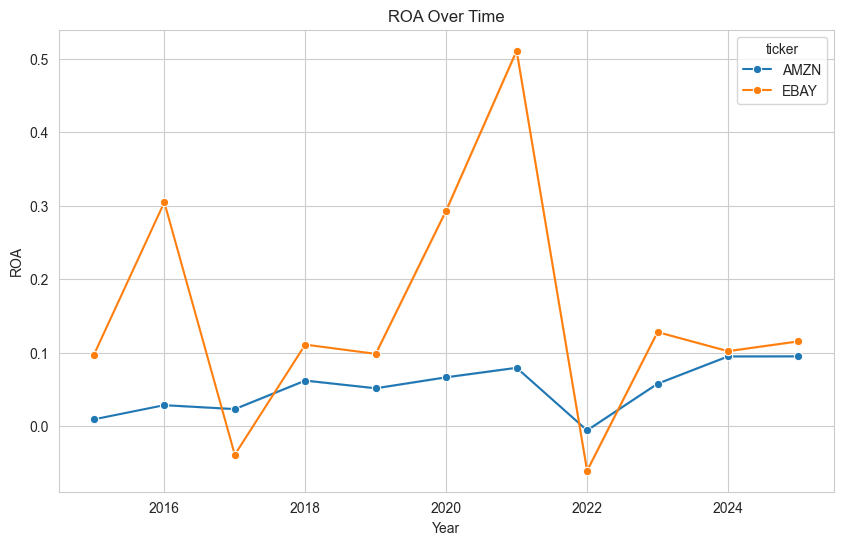

In [139]:
#ROA trend
plt.figure(figsize=(10, 6))
sns.lineplot(data=comp_ecom, x='year', y='roa_w', hue='ticker', marker='o')
plt.title('ROA Over Time')
plt.xlabel('Year')
plt.ylabel('ROA')
plt.show()

## Download stock market data
Monthly stock return data are obtained from CRSP for Amazon and eBay.

In [140]:
permno_list = ",".join(map(str, target_permnos))

crsp_sql = f"""
SELECT permno, date, ret
FROM crsp.msf
WHERE ret IS NOT NULL
  AND date >= '2015-01-01'
  AND permno IN ({permno_list})
"""
crsp = db.raw_sql(crsp_sql)

crsp['date'] = pd.to_datetime(crsp['date'])
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')
crsp = crsp.dropna(subset=['ret'])
crsp['year'] = crsp['date'].dt.year

print("CRSP monthly return shape:", crsp.shape)
crsp.head()

CRSP monthly return shape: (240, 4)


,permno,date,ret,year
0,84788,2015-01-30,0.142355,2015
1,84788,2015-02-27,0.072293,2015
2,84788,2015-03-31,-0.021202,2015
3,84788,2015-04-30,0.133512,2015
4,84788,2015-05-29,0.017663,2015


## Annual stock return
Annual stock return is calculated by compounding monthly returns within each year.

In [141]:
annual_ret = crsp.groupby(['permno', 'year'])['ret'].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()

annual_ret = annual_ret.rename(columns={'ret': 'annual_return'})

print("Annual return shape:", annual_ret.shape)
annual_ret.head()

Annual return shape: (20, 3)


,permno,year,annual_return
0,84788,2015,1.177831
1,84788,2016,0.109455
2,84788,2017,0.559565
3,84788,2018,0.284317
4,84788,2019,0.230279


## Combine accounting and market information
The final dataset contains annual accounting measures and annual stock returns for the two firms.

In [142]:
final_df = pd.merge(
    comp_ecom,
    annual_ret,
    on=['permno', 'year'],
    how='inner'
)

final_df = final_df.dropna(subset=['roa', 'annual_return'])
final_df = final_df[np.isfinite(final_df['roa'])]
final_df = final_df[np.isfinite(final_df['annual_return'])]

print("Final sample shape:", final_df.shape)
final_df[['ticker', 'comnam', 'year', 'sale', 'ni', 'at', 'roa', 'annual_return']].head()

Final sample shape: (35, 20)


,ticker,comnam,year,sale,ni,at,roa,annual_return
0,AMZN,AMAZON COM INC,2015,107006.0,596.0,65444.0,0.009107,1.177831
1,AMZN,AMAZON COM INC,2016,135987.0,2371.0,83402.0,0.028429,0.109455
2,AMZN,AMAZON COM INC,2016,135987.0,2371.0,83402.0,0.028429,0.109455
3,AMZN,AMAZON COM INC,2017,177866.0,3033.0,131310.0,0.023098,0.559565
4,AMZN,AMAZON COM INC,2017,177866.0,3033.0,131310.0,0.023098,0.559565


## Compare annual stock return by company

In [143]:
market_summary = final_df.groupby('ticker')[['annual_return']].mean().reset_index()
market_summary

,ticker,annual_return
0,AMZN,0.348994
1,EBAY,0.169214


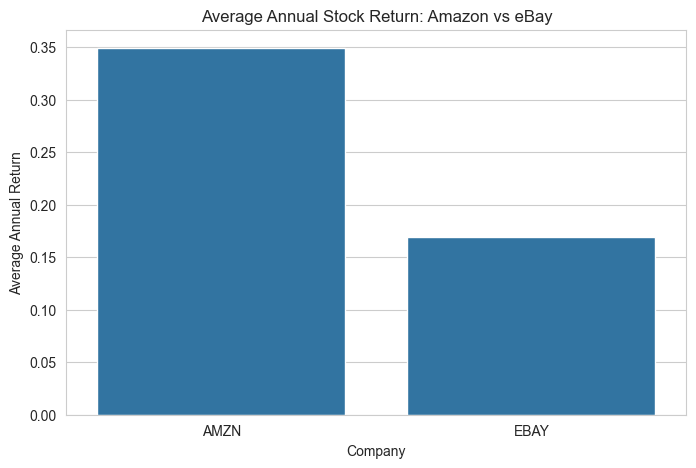

In [144]:
plt.figure(figsize=(8, 5))
sns.barplot(data=market_summary, x='ticker', y='annual_return')
plt.title('Average Annual Stock Return: Amazon vs eBay')
plt.xlabel('Company')
plt.ylabel('Average Annual Return')
plt.show()

## Annual stock return over time

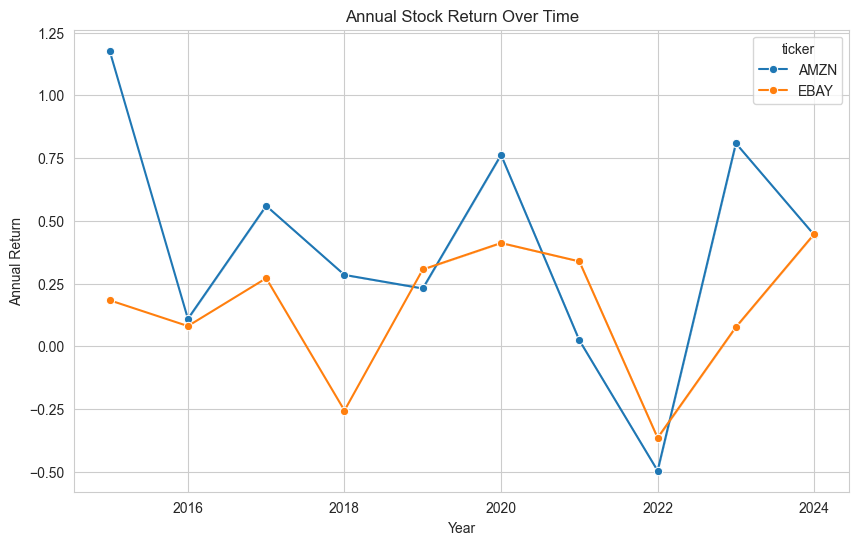

In [145]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=final_df, x='year', y='annual_return', hue='ticker', marker='o')
plt.title('Annual Stock Return Over Time')
plt.xlabel('Year')
plt.ylabel('Annual Return')
plt.show()

## Combined summary table
This table presents both accounting performance and stock market performance in one place.

In [146]:
combined_summary = final_df.groupby('ticker')[['sale_w', 'ni_w', 'at_w', 'roa_w', 'annual_return']].mean().reset_index()
combined_summary

,ticker,sale_w,ni_w,at_w,roa_w,annual_return
0,AMZN,364566.105263,17790.421053,314999.684211,0.048608,0.348994
1,EBAY,9808.74625,3723.3125,21395.125,0.163583,0.169214


## Profitability and market performance
The scatter plot below illustrates whether years with higher ROA are also associated with stronger stock returns for the two firms.

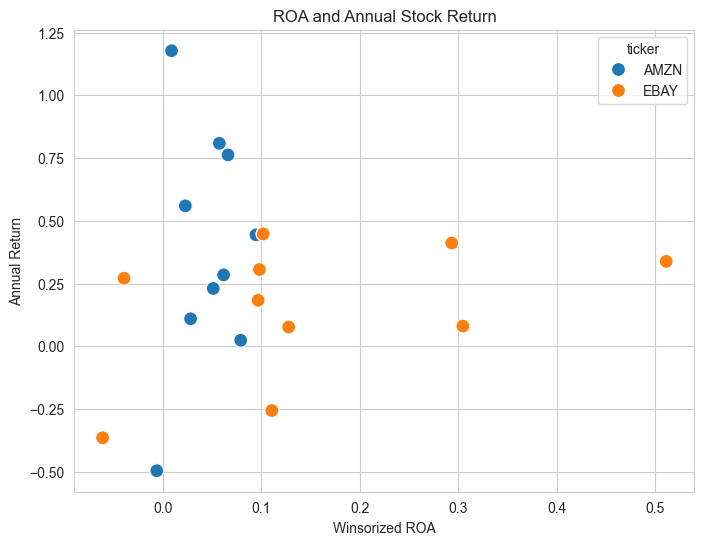

In [147]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x='roa_w', y='annual_return', hue='ticker', s=100)
plt.title('ROA and Annual Stock Return')
plt.xlabel('Winsorized ROA')
plt.ylabel('Annual Return')
plt.show()

## Correlation analysis
The correlation coefficient is reported as a simple summary of the linear association between ROA and annual stock return.

In [148]:
corr_total = final_df['roa_w'].corr(final_df['annual_return'])
print("Overall correlation between ROA and annual return:", corr_total)

for ticker in final_df['ticker'].dropna().unique():
    sub = final_df[final_df['ticker'] == ticker]
    if len(sub) > 1:
        corr_company = sub['roa_w'].corr(sub['annual_return'])
        print(f"{ticker} correlation:", corr_company)

Overall correlation between ROA and annual return: 0.14889628290067367
AMZN correlation: 0.2842285095324994
EBAY correlation: 0.4966560192111833


## Regression analysis
To examine whether accounting performance is associated with stock market performance, regression analysis is used with annual stock return as the dependent variable.

In [152]:
reg_df = final_df[['annual_return', 'roa_w']].copy()

reg_df['annual_return'] = pd.to_numeric(reg_df['annual_return'], errors='coerce')
reg_df['roa_w'] = pd.to_numeric(reg_df['roa_w'], errors='coerce')

reg_df = reg_df.dropna()

model1 = smf.ols('annual_return ~ roa_w', data=reg_df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_return   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.7482
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.393
Time:                        16:24:13   Log-Likelihood:                -14.447
No. Observations:                  35   AIC:                             32.89
Df Residuals:                      33   BIC:                             36.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2241      0.081      2.781      0.0

## Interpretation

This notebook compares Amazon and eBay using both accounting data and stock return data. The accounting analysis focuses on sales, total assets, net income, and ROA, while the market analysis focuses on annual stock return.

The results help us compare the two firms in terms of business size, profitability, and market performance. In particular, ROA is used to examine whether stronger profitability is associated with better stock return performance. The figures and summary tables provide a direct comparison between the two companies, while the correlation and regression analysis give a simple quantitative test of the relationship between ROA and annual return.

However, the results should be interpreted with caution. Even if a positive relationship appears in the data, stock returns are affected by many factors beyond accounting profitability. For example, investor expectations, growth opportunities, and overall market conditions may all influence return performance.

Therefore, this notebook should be understood as a focused comparison of two e-commerce firms rather than a broad test of all firms in the market.## Interpretation

## Limitations

This analysis has several limitations. The sample includes only two firms, so the findings cannot be generalized to the entire e-commerce sector. In addition, stock returns are influenced by many factors beyond accounting performance. Therefore, the results should be interpreted as exploratory evidence rather than strong causal proof.

## Conclusion

This notebook examines Amazon and eBay as two representative e-commerce firms and compares them using accounting and stock market data. The analysis shows that the two firms differ in firm size, profitability, and annual stock return over the sample period.

The notebook also explores whether higher ROA is associated with higher stock return. The results suggest that accounting performance may help explain part of the variation in stock performance, but the relationship is not exact or purely causal.

In summary, the project provides a company-level comparison of financial and market performance in the e-commerce sector. It also shows that profitability is an important indicator, but it should not be treated as the only factor affecting stock return.